In [20]:
from functools import reduce
from pyspark.sql.functions import (col, trim, lower, regexp_replace, sum, udf, to_timestamp,split, datediff, substring, length,
    current_timestamp, when, datediff, try_to_timestamp, to_date)
from pythainlp import word_tokenize
from pyspark.sql.types import ArrayType, StringType
from pythainlp.corpus import thai_stopwords
from xgboost.spark import SparkXGBRegressor 


In [21]:
spark_url = 'local'
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType

spark = SparkSession.builder \
    .appName("XGBoost_Clean_Run") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .master("local[*]") \
    .getOrCreate()

In [48]:
sc = spark.sparkContext

# Path เดียวกันกับที่คุณใช้ในการบันทึก
OUTPUT_PATH_SUBSET = "file:///E:/2_1/ds/project/output_csv"

# อ่านไฟล์ที่บันทึกไว้กลับเข้ามา
df_processed = spark.read.csv(
    OUTPUT_PATH_SUBSET, 
    header=True,
    # ต้องระบุ encoding อีกครั้ง!
    encoding="UTF-8" 
)

print("Schema หลังโหลดข้อมูลใหม่:")
df_processed.printSchema()

Schema หลังโหลดข้อมูลใหม่:
root
 |-- ticket_id: string (nullable = true)
 |-- address: string (nullable = true)
 |-- district: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- lon: string (nullable = true)
 |-- DaysActive_Pending: string (nullable = true)
 |-- comment_clean: string (nullable = true)
 |-- timestamp_dt: string (nullable = true)
 |-- last_activity_dt: string (nullable = true)
 |-- type_ถนน: string (nullable = true)
 |-- type_ทางเท้า: string (nullable = true)
 |-- type_ความปลอดภัย: string (nullable = true)
 |-- type_แสงสว่าง: string (nullable = true)
 |-- type_ความสะอาด: string (nullable = true)
 |-- type_กีดขวาง: string (nullable = true)
 |-- type_ท่อระบายน้ำ: string (nullable = true)
 |-- type_น้ำท่วม: string (nullable = true)
 |-- type_ต้นไม้: string (nullable = true)
 |-- type_PM25: string (nullable = true)
 |-- type_จราจร: string (nullable = true)
 |-- type_สะพาน: string (nullable = true)
 |-- year_reported: string (nullable = true)
 |-- year_last_acti

In [ ]:
from pyspark.sql.functions import col

df_summary = df_processed.groupBy("district", "year_reported") \
    .count() \
    .orderBy("district", "year_reported") # เรียง ก-ฮ และ ปีเก่า-ใหม่

df_summary.show(10, truncate=False)

+---------+-------------+-----+
|district |year_reported|count|
+---------+-------------+-----+
|คลองสาน  |2022         |109  |
|คลองสาน  |2023         |133  |
|คลองสาน  |2024         |388  |
|คลองสาน  |2025         |73   |
|คลองสามวา|2022         |137  |
|คลองสามวา|2023         |442  |
|คลองสามวา|2024         |855  |
|คลองสามวา|2025         |67   |
|คลองเตย  |2022         |245  |
|คลองเตย  |2023         |1008 |
+---------+-------------+-----+
only showing top 10 rows


In [23]:

df_current = df_processed 

# 1. กำหนดคอลัมน์ที่ต้องแปลง
float_cols = ["lat", "lon", "DaysActive_Pending"]
int_cols = [
    "type_ถนน", "type_ทางเท้า", "type_ความปลอดภัย", "type_แสงสว่าง", 
    "type_ความสะอาด", "type_กีดขวาง", "type_ท่อระบายน้ำ", "type_น้ำท่วม", 
    "type_ต้นไม้", "type_PM25", "type_จราจร", "type_สะพาน",
    "year_reported", "year_last_activity"
]

# 2. แปลงคอลัมน์ Float และ Integer
for c in float_cols:
    df_current = df_current.withColumn(c, col(c).cast("float"))

for c in int_cols:
    df_current = df_current.withColumn(c, col(c).cast("int"))



df_ml_ready = df_current.drop("timestamp_dt", "last_activity_dt","address","comment_clean","year_reported","year_last_activity","lat","lon")

print("Columns timestamp_dt and last_activity_dt have been dropped.")

# ตรวจสอบ Schema ใหม่
print("The updated schema is:")
df_ml_ready.printSchema()
df_ml_ready.count()

Columns timestamp_dt and last_activity_dt have been dropped.
The updated schema is:
root
 |-- ticket_id: string (nullable = true)
 |-- district: string (nullable = true)
 |-- DaysActive_Pending: float (nullable = true)
 |-- type_ถนน: integer (nullable = true)
 |-- type_ทางเท้า: integer (nullable = true)
 |-- type_ความปลอดภัย: integer (nullable = true)
 |-- type_แสงสว่าง: integer (nullable = true)
 |-- type_ความสะอาด: integer (nullable = true)
 |-- type_กีดขวาง: integer (nullable = true)
 |-- type_ท่อระบายน้ำ: integer (nullable = true)
 |-- type_น้ำท่วม: integer (nullable = true)
 |-- type_ต้นไม้: integer (nullable = true)
 |-- type_PM25: integer (nullable = true)
 |-- type_จราจร: integer (nullable = true)
 |-- type_สะพาน: integer (nullable = true)



100379

In [24]:
from pyspark.sql.functions import col, sum

# 1. ดึงรายชื่อคอลัมน์ทั้งหมดที่ขึ้นต้นด้วย "type_"
type_cols = [c for c in df_ml_ready.columns if c.startswith("type_")]

# 2. สั่ง Sum ทุกคอลัมน์พร้อมกัน
# ใช้ list comprehension สร้าง expression แล้วแตก list ด้วย *
df_type_counts = df_ml_ready.agg(*[sum(col(c)).alias(c) for c in type_cols])



In [25]:
from pyspark.sql.functions import expr

# 1. เตรียม Expression (แก้ไขจุดนี้) 🔧
columns = df_type_counts.columns

# ❌ ของเดิม: f"'{c}', {c}"  -> Spark อ่านเจอ type_ถนน แล้วงง
# ✅ ของใหม่: f"'{c}', `{c}`" -> Spark อ่านเจอ `type_ถนน` แล้วเข้าใจว่าเป็นชื่อคอลัมน์
stack_expression = ", ".join([f"'{c}', `{c}`" for c in columns])

num_columns = len(columns)

# 2. ทำการ Stack (ใช้ default col0, col1 ไปก่อน)
df_unpivoted = df_type_counts.select(
    expr(f"stack({num_columns}, {stack_expression})")
)

# 3. เปลี่ยนชื่อคอลัมน์ให้สื่อความหมาย
df_save = df_unpivoted.withColumnRenamed("col0", "Problem_Type") \
                      .withColumnRenamed("col1", "Total_Count")

# ลองแสดงผล
print("--- ตัวอย่างข้อมูลที่จะบันทึก ---")
df_save.show(truncate=False)

# 4. สั่งบันทึก
OUTPUT_PATH = "problem_type_summary_spark"
df_save.coalesce(1).write.csv(
    OUTPUT_PATH, 
    header=True, 
    mode="overwrite", 
    encoding="UTF-8"
)

print(f"✅ บันทึกเสร็จเรียบร้อยที่: {OUTPUT_PATH}")

--- ตัวอย่างข้อมูลที่จะบันทึก ---
+----------------+-----------+
|Problem_Type    |Total_Count|
+----------------+-----------+
|type_ถนน        |45642      |
|type_ทางเท้า    |18586      |
|type_ความปลอดภัย|21143      |
|type_แสงสว่าง   |17182      |
|type_ความสะอาด  |4098       |
|type_กีดขวาง    |9268       |
|type_ท่อระบายน้ำ|6171       |
|type_น้ำท่วม    |4385       |
|type_ต้นไม้     |2583       |
|type_PM25       |867        |
|type_จราจร      |11622      |
|type_สะพาน      |9497       |
+----------------+-----------+

✅ บันทึกเสร็จเรียบร้อยที่: problem_type_summary_spark


In [26]:
from pyspark.sql.functions import col, trim, regexp_replace, count

# รายชื่อ 50 เขตอย่างเป็นทางการของกรุงเทพมหานคร
BANGKOK_50_DISTRICTS = [
    "คลองสาน", "คลองสามวา", "คลองเตย", "คันนายาว", "จตุจักร", "จอมทอง", 
    "ดอนเมือง", "ดินแดง", "ดุสิต", "ตลิ่งชัน", "ทวีวัฒนา", "ทุ่งครุ", 
    "ธนบุรี", "บางกอกน้อย", "บางกอกใหญ่", "บางกะปิ", "บางขุนเทียน", 
    "บางคอแหลม", "บางซื่อ", "บางนา", "บางบอน", "บางพลัด", "บางรัก", 
    "บางเขน", "บางแค", "บึงกุ่ม", "ปทุมวัน", "ประเวศ", "ป้อมปราบศัตรูพ่าย", 
    "พญาไท", "พระนคร", "พระโขนง", "ภาษีเจริญ", "มีนบุรี", "ยานนาวา", 
    "ราชเทวี", "ราษฎร์บูรณะ", "ลาดกระบัง", "ลาดพร้าว", "วังทองหลาง", 
    "วัฒนา", "สวนหลวง", "สะพานสูง", "สัมพันธวงศ์", "สาทร", "สายไหม", 
    "หนองจอก", "หนองแขม", "หลักสี่", "ห้วยขวาง"
]
# ใช้ DataFrame ข้อมูล Ticket ที่คุณใช้ในการคำนวณ Livability Score (df_ml_ready)

# 1. ทำความสะอาดอย่างเข้มงวดที่สุด
df_cleaned = df_ml_ready.withColumn("district_cleaned", col("district"))

# ลบอักขระที่มองไม่เห็นทั้งหมด (Non-printable/control characters)
# เช่น \u200b, \u0000, \u0001, ฯลฯ
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    regexp_replace(col("district_cleaned"), "[\\p{C}]", "") 
)


# แก้ไข Typo และลบช่องว่างหลายช่องให้เหลือช่องว่างเดียว
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    regexp_replace(col("district_cleaned"), "ป้อมปราบศัตรูพ่า", "ป้อมปราบศัตรูพ่าย")
)
df_cleaned = df_cleaned.withColumn(
    "district_cleaned", 
    regexp_replace(col("district_cleaned"), "ป้อมปราบศัตรูพ่ายย", "ป้อมปราบศัตรูพ่าย") # 💡 แก้ไข Typo ใหม่
)
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    regexp_replace(col("district_cleaned"), "\\s+", " ")
)

# Trim สุดท้ายเพื่อลบช่องว่างหัวท้ายที่อาจหลงเหลือ
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    trim(col("district_cleaned"))
)

# 2. ใช้ district_cleaned แทน district เดิม
df_ml_ready_filtered = df_cleaned.drop("district") \
                                 .withColumnRenamed("district_cleaned", "district")

# 3. กรองเฉพาะ 50 เขตของกรุงเทพฯ เท่านั้น
df_ml_ready_filtered = df_ml_ready_filtered.filter(
    col("district").isin(BANGKOK_50_DISTRICTS)
)

# 4. ตรวจสอบจำนวนเขตสุดท้าย
df_ml_ready_filtered.cache()
count_after_filter = df_ml_ready_filtered.count()
final_district_count = df_ml_ready_filtered.select("district").distinct().count()

df_ml_ready_filtered.select("district").distinct().show(60)
print(f"จำนวนเขตสุดท้ายที่ถูกต้อง: {final_district_count} เขต")

+-----------------+
|         district|
+-----------------+
|         ตลิ่งชัน|
|         ดอนเมือง|
|           บางรัก|
|           ประเวศ|
|           บางบอน|
|            ดุสิต|
|            พญาไท|
|          หนองจอก|
|          ราชเทวี|
|      บางขุนเทียน|
|            บางแค|
|      ราษฎร์บูรณะ|
|          คลองเตย|
|           จอมทอง|
|        คลองสามวา|
|       บางกอกใหญ่|
|          ทุ่งครุ|
|         ลาดพร้าว|
|           บางเขน|
|         ทวีวัฒนา|
|         สะพานสูง|
|           ธนบุรี|
|          บึงกุ่ม|
|           ดินแดง|
|          บางกะปิ|
|          ปทุมวัน|
|         ห้วยขวาง|
|        ลาดกระบัง|
|          บางซื่อ|
|          สวนหลวง|
|          ยานนาวา|
|           สายไหม|
|           พระนคร|
|          จตุจักร|
|            วัฒนา|
|       วังทองหลาง|
|          พระโขนง|
|            บางนา|
|        บางคอแหลม|
|         คันนายาว|
|       บางกอกน้อย|
|          มีนบุรี|
|        ภาษีเจริญ|
|          หลักสี่|
|          หนองแขม|
|      สัมพันธวงศ์|
|          คลองสาน|


In [27]:
from pyspark.sql.functions import  lit

# สมมติว่านี่คือการเริ่มต้น session ใหม่ ถ้าไม่ ให้ข้ามไปขั้นตอนถัดไป
# spark = SparkSession.builder.appName("GeoSpatialJoin").getOrCreate()

CONDO_FILE_PATH = "ddproperty_processed.csv" 
# โปรดเปลี่ยนเป็น path จริงหากคุณไม่ได้อัปโหลดไฟล์ผ่านเครื่องมือ

df_condo_raw = spark.read.csv(
    CONDO_FILE_PATH,
    header=True,
    encoding="UTF-8",
    inferSchema=True  # ให้ Spark ลองเดาประเภทข้อมูล
)


df_condo_raw.printSchema()


root
 |-- url: string (nullable = true)
 |-- title: string (nullable = true)
 |-- publish_date: date (nullable = true)
 |-- price: double (nullable = true)
 |-- price_per_sqm: double (nullable = true)
 |-- usable_area: double (nullable = true)
 |-- bedroom: double (nullable = true)
 |-- restroom: double (nullable = true)
 |-- coords: string (nullable = true)
 |-- full_address: string (nullable = true)
 |-- sub_district: string (nullable = true)
 |-- district: string (nullable = true)
 |-- province: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)



In [28]:
df_condo_clean = df_condo_raw.drop("url","price_per_sqm", "coords", "full_address","sub_district","province","postcode","latitude","longitude")
df_condo_clean.printSchema()
df_condo_clean.show(5)

root
 |-- title: string (nullable = true)
 |-- publish_date: date (nullable = true)
 |-- price: double (nullable = true)
 |-- usable_area: double (nullable = true)
 |-- bedroom: double (nullable = true)
 |-- restroom: double (nullable = true)
 |-- district: string (nullable = true)

+--------------------+------------+---------+-----------+-------+--------+--------+
|               title|publish_date|    price|usable_area|bedroom|restroom|district|
+--------------------+------------+---------+-----------+-------+--------+--------+
|The Old Siam Resi...|  2025-11-26|6480000.0|      100.0|    2.0|     2.0|  พระนคร|
|Juldis River Mans...|  2025-11-21|3500000.0|       37.0|    1.0|     1.0|  พระนคร|
|The Old Siam Resi...|  2025-11-20|7050000.0|      118.0|    2.0|     2.0|  พระนคร|
|Juldis River Mans...|  2025-11-20|2790000.0|       41.0|    1.0|     1.0|  พระนคร|
|The Old Siam Resi...|  2025-11-15|6320000.0|      100.0|    2.0|     2.0|  พระนคร|
+--------------------+------------+---------

In [29]:
from pyspark.sql.functions import col, regexp_replace, trim

# 1. ทำความสะอาดช่องว่างและลบ "เขต" ออก
df_condo_clean = df_condo_clean.withColumn(
    "district_cleaned", 
    trim(col("district"))
)
df_condo_clean = df_condo_clean.withColumn(
    "district_cleaned", 
    trim(col("district_cleaned")) # ลบช่องว่างที่อาจเหลือ
)


In [30]:

# 2. Drop คอลัมน์เก่าและ Rename คอลัมน์ใหม่
df_condo_clean = df_condo_clean.drop("district") \
                               .withColumnRenamed("district_cleaned", "district")



# # 4. ตรวจสอบผลลัพธ์
df_condo_clean.select("district").distinct().count()
# df_condo_clean.show(10, truncate=False)

49

In [31]:
# 1. (สำคัญ) Cache ข้อมูลก่อนเพื่อตัด Lineage ที่ซับซ้อน
# หาก df_condo_clean ผ่านการ clean มาเยอะ การ cache จะช่วยให้ไม่ timeout
df_condo_clean.cache()
print(f"จำนวนแถวข้อมูลคอนโด: {df_condo_clean.count()}") # บังคับให้ประมวลผลและ Cache

# 2. ดึงชื่อเขตที่ไม่ซ้ำกันมาเป็น List (โดยไม่ใช้ RDD)
# .collect() จะได้ List ของ Row objects [Row(district='A'), Row(district='B'), ...]
rows = df_condo_clean.select("district").distinct().collect()

# 3. แปลง Row เป็น String ด้วย Python List Comprehension
condo_districts_set = set([row['district'] for row in rows])

# 4. เปรียบเทียบกับ List มาตรฐาน 50 เขต
all_districts_set = set(BANGKOK_50_DISTRICTS)

# หาเขตที่หายไป (Set Difference)
missing_districts = all_districts_set - condo_districts_set

print(f"เขตที่ไม่มีข้อมูลคอนโด ({len(missing_districts)} เขต) คือ: {missing_districts}")

จำนวนแถวข้อมูลคอนโด: 7346
เขตที่ไม่มีข้อมูลคอนโด (1 เขต) คือ: {'ทวีวัฒนา'}


In [32]:
from pyspark.sql.functions import col, count, avg, sum

# 1. จัดกลุ่มด้วยเขต และคำนวณตัวชี้วัดปัญหา
df_district_metrics = df_ml_ready_filtered.groupBy("district").agg(
    # A. Total Problem Count (ปริมาณปัญหาทั้งหมด)
    count(col("ticket_id")).alias("Total_Problem_Count"),
    
    # B. Average Severity (ความรุนแรงเฉลี่ย: ระยะเวลารอแก้ไข)
    avg(col("DaysActive_Pending")).alias("Avg_Pending_Days"),
    
    # C. Weighted Problem Type Index (ดัชนีปัญหาเฉพาะทาง - ให้ความปลอดภัยสำคัญสุด)
    # *หมายเหตุ: type_... ต้องถูก cast เป็น Int ก่อนแล้ว
    (
        (sum(col("type_ความปลอดภัย")) * 3) + 
        (sum(col("type_ทางเท้า")) * 2) +           
        (sum(col("type_น้ำท่วม")) * 3) +
        (sum(col("type_แสงสว่าง")) * 1)  +
        (sum(col("type_กีดขวาง")) * 2) +  
        (sum(col("type_ท่อระบายน้ำ")) * 2) +   
        (sum(col("type_ความสะอาด")) * 2) +          
        (sum(col("type_ถนน")) * 2) +
        (sum(col("type_ต้นไม้")) * 1)+
        (sum(col("type_PM25")) * 2) +          
        (sum(col("type_จราจร")) * 2) +
        (sum(col("type_สะพาน")) * 1)      
    ).alias("Weighted_Problem_Index")
)

print("--- ตัวชี้วัดปัญหาต่อเขต (ก่อน Normalization) ---")
df_district_metrics.orderBy(col("Avg_Pending_Days").desc()).show(5, truncate=False)

--- ตัวชี้วัดปัญหาต่อเขต (ก่อน Normalization) ---
+-----------+-------------------+-----------------+----------------------+
|district   |Total_Problem_Count|Avg_Pending_Days |Weighted_Problem_Index|
+-----------+-------------------+-----------------+----------------------+
|บางขุนเทียน|3076               |764.924577373212 |8996                  |
|หลักสี่    |1495               |753.4635451505017|4515                  |
|ตลิ่งชัน   |2281               |739.0482244629549|6695                  |
|ราษฎร์บูรณะ|789                |719.7313054499366|2367                  |
|จตุจักร    |5646               |714.8000354233085|16619                 |
+-----------+-------------------+-----------------+----------------------+
only showing top 5 rows


In [33]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.sql.functions import lit, round

# 1. รวมคอลัมน์ปัญหาทั้งหมดเข้าด้วยกัน
feature_cols = ["Total_Problem_Count", "Avg_Pending_Days", "Weighted_Problem_Index"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_vector"
)
df_vector = assembler.transform(df_district_metrics)

# 2. ทำ Min-Max Scaling (ปรับค่าให้อยู่ในช่วง 0 ถึง 1)
scaler = MinMaxScaler(
    inputCol="features_vector", 
    outputCol="normalized_features"
)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# 3. ดึงค่า Normalized กลับมาเป็นคอลัมน์ (ใช้ค่าแรกใน SparseVector)
# เนื่องจากเราไม่สามารถดึงค่าจาก Vector ใน PySpark ได้ง่าย ๆ เราจะใช้เทคนิคการ Scale ซ้ำ
# หรือในทางปฏิบัติที่ง่ายกว่าคือการคำนวณสูตร Min-Max ด้วยมือ (สำหรับตอนนี้)

In [34]:
from pyspark.sql.functions import col, min, max, lit, round, min, max

# 1. คำนวณค่า Min/Max สำหรับแต่ละตัวชี้วัด (แก้ไขโดยใช้ col() หุ้มชื่อคอลัมน์)
min_max_values = df_district_metrics.select(
    min(col("Total_Problem_Count")).alias("min_count"),
    max(col("Total_Problem_Count")).alias("max_count"),
    min(col("Avg_Pending_Days")).alias("min_days"),
    max(col("Avg_Pending_Days")).alias("max_days"),
    min(col("Weighted_Problem_Index")).alias("min_weight"),
    max(col("Weighted_Problem_Index")).alias("max_weight")
).collect()[0]

# ดึงค่า Min/Max
min_count, max_count = min_max_values["min_count"], min_max_values["max_count"]
min_days, max_days = min_max_values["min_days"], min_max_values["max_days"]
min_weight, max_weight = min_max_values["min_weight"], min_max_values["max_weight"]

# 2. สร้าง "ดัชนีความไม่น่าอยู่" (Unlivability Index)
df_scored = df_district_metrics.withColumn(
    # Normalize Count
    "Norm_Count", 
    (col("Total_Problem_Count") - lit(min_count)) / lit(max_count - min_count)
).withColumn(
    # Normalize Pending Days
    "Norm_Days", 
    (col("Avg_Pending_Days") - lit(min_days)) / lit(max_days - min_days)
).withColumn(
    # Normalize Weighted Index
    "Norm_Weight", 
    (col("Weighted_Problem_Index") - lit(min_weight)) / lit(max_weight - min_weight)
)

from pyspark.sql.functions import col, lit, round

# 3. รวมดัชนีเข้าด้วยกัน
df_final_index = df_scored.withColumn(
    "Unlivability_Index",
    round(
        (col("Norm_Count") * 0.3) +        # น้ำหนัก 30%
        (col("Norm_Days") * 0.4) +         # น้ำหนัก 40%
        (col("Norm_Weight") * 0.3),        # น้ำหนัก 30%
        4
    )
)

# 4. แปลงเป็น "Livability Score" ที่มีคะแนนเต็ม 10
df_final_score = df_final_index.withColumn(
    # คำนวณ Livability Score (1.0 - Unlivability Index)
    "Livability_Score_0_1",
    lit(1.0) - col("Unlivability_Index")
).withColumn(
    # ปรับคะแนนจาก 0-1 ให้เป็น 0-10 และปัดทศนิยม 2 ตำแหน่ง
    "Livability_Score_10",
    round(col("Livability_Score_0_1") * 10, 2)
).drop("Livability_Score_0_1") # ลบคอลัมน์ 0-1 ทิ้ง

# 5. จัดอันดับเขตที่ "น่าอยู่ที่สุด" (Livability_Score_10 สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score เต็ม 10) ---")
df_final_score.select(
    "district", 
    "Livability_Score_10", 
    "Total_Problem_Count",
    "Avg_Pending_Days"
).orderBy(col("Livability_Score_10").desc()).show(5, truncate=False)


--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score เต็ม 10) ---
+-----------------+-------------------+-------------------+-----------------+
|district         |Livability_Score_10|Total_Problem_Count|Avg_Pending_Days |
+-----------------+-------------------+-------------------+-----------------+
|สัมพันธวงศ์      |10.0               |465                |552.9935483870968|
|หนองแขม          |8.66               |692                |612.8468208092486|
|บางบอน           |8.52               |974                |599.8757700205339|
|บางกอกใหญ่       |8.37               |697                |627.2912482065997|
|ป้อมปราบศัตรูพ่าย|8.18               |1381               |585.427226647357 |
+-----------------+-------------------+-------------------+-----------------+
only showing top 5 rows


In [35]:
# จัดอันดับเขตที่ "น่าอยู่ที่สุด" (Livability_Score สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score สูงสุด) ---")
df_final_score.select(
    "district", 
    "Livability_Score_10", 
    "Total_Problem_Count",
    "Avg_Pending_Days"
).orderBy(col("Livability_Score_10").desc()).show(5, truncate=False)

# จัดอันดับเขตที่ "น่าอยู่น้อยที่สุด" (Unlivability_Index สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่น้อยที่สุด (Livability Score ต่ำสุด) ---")
df_final_score.select(
    "district", 
    "Livability_Score_10", 
    "Total_Problem_Count",
    "Avg_Pending_Days"
).orderBy(col("Livability_Score_10").asc()).show(5, truncate=False)


--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score สูงสุด) ---
+-----------------+-------------------+-------------------+-----------------+
|district         |Livability_Score_10|Total_Problem_Count|Avg_Pending_Days |
+-----------------+-------------------+-------------------+-----------------+
|สัมพันธวงศ์      |10.0               |465                |552.9935483870968|
|หนองแขม          |8.66               |692                |612.8468208092486|
|บางบอน           |8.52               |974                |599.8757700205339|
|บางกอกใหญ่       |8.37               |697                |627.2912482065997|
|ป้อมปราบศัตรูพ่าย|8.18               |1381               |585.427226647357 |
+-----------------+-------------------+-------------------+-----------------+
only showing top 5 rows

--- อันดับเขตที่น่าอยู่น้อยที่สุด (Livability Score ต่ำสุด) ---
+-----------+-------------------+-------------------+-----------------+
|district   |Livability_Score_10|Total_Problem_Count|Avg_Pending_Days |
+---

In [39]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.evaluation import RegressionEvaluator
from xgboost.spark import SparkXGBRegressor

# 2. เริ่ม Process
df_scores = df_final_score.select(col("district"), col("Livability_Score_10"))

# Join
df_joined = df_condo_clean.join(df_scores, on="district", how="left")

# ตรวจสอบการ Join ทันที
match_count = df_joined.filter(col("Livability_Score_10").isNotNull()).count()
print(f"DEBUG: Join คะแนนความน่าอยู่ติด {match_count} จาก {df_joined.count()} แถว")

feature_cols = ["usable_area", "bedroom", "restroom", "Livability_Score_10"]
from pyspark.sql.functions import log
df_log_price = df_joined.withColumn("log_price", log(col("price")))
# Cast Types
for c in feature_cols + ["price"]:
    df_joined = df_log_price.withColumn(c, col(c).cast("double"))
from pyspark.sql.functions import log
# Impute
imputer = Imputer(inputCols=feature_cols, outputCols=feature_cols).setStrategy("mean")
df_clean = imputer.fit(df_joined).transform(df_joined)

# Drop Null Prices
df_clean = df_clean.na.drop(subset=["log_price"])

# Check Data Count
data_count = df_clean.count()
print(f"DEBUG: ข้อมูลพร้อมเทรน {data_count} แถว")
df_clean.show(10)


DEBUG: Join คะแนนความน่าอยู่ติด 7346 จาก 7346 แถว
DEBUG: ข้อมูลพร้อมเทรน 7346 แถว
+--------+--------------------+------------+---------+-----------+-------+--------+-------------------+------------------+
|district|               title|publish_date|    price|usable_area|bedroom|restroom|Livability_Score_10|         log_price|
+--------+--------------------+------------+---------+-----------+-------+--------+-------------------+------------------+
|  พระนคร|The Old Siam Resi...|  2025-11-26|6480000.0|      100.0|    2.0|     2.0|               7.12|15.684231068328458|
|  พระนคร|Juldis River Mans...|  2025-11-21|3500000.0|       37.0|    1.0|     1.0|               7.12|15.068273526459642|
|  พระนคร|The Old Siam Resi...|  2025-11-20|7050000.0|      118.0|    2.0|     2.0|               7.12|15.768538174788452|
|  พระนคร|Juldis River Mans...|  2025-11-20|2790000.0|       41.0|    1.0|     1.0|               7.12|14.841552153797549|
|  พระนคร|The Old Siam Resi...|  2025-11-15|6320000.0|   

In [43]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# df_clean คือ DataFrame ล่าสุดที่คุณโชว์ให้ผมดู
# แปลง features และกำหนด label เป็น 'price'
df_final_ml = assembler.transform(df_clean).select("features", col("log_price").alias("label"))

# 2. แบ่งข้อมูล 70/30
train_data, test_data = df_final_ml.randomSplit([0.7, 0.3], seed=42)

print(f"--- พร้อมเทรนโมเดล ---")
print(f"Train Set: {train_data.count()} แถว")
print(f"Test Set:  {test_data.count()} แถว")
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. แปลงข้อมูลจาก Spark DataFrame เป็น Pandas DataFrame
# ข้อมูล 7,000 แถว ใช้ RAM น้อยมาก ทำได้สบายๆ
print("⏳ กำลังแปลงข้อมูลเป็น Pandas format...")
pdf_train = train_data.toPandas()
pdf_test = test_data.toPandas()

# 2. แยก Features (X) และ Label (y)
# เนื่องจาก Spark เก็บ features เป็น Vector เราต้องแกะมันออกมาเป็น Numpy Array
X_train = np.array(pdf_train["features"].tolist())
y_train = pdf_train["label"].values

X_test = np.array(pdf_test["features"].tolist())
y_test = pdf_test["label"].values

print(f"✅ แปลงข้อมูลเสร็จสิ้น!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

# 3. สร้างและเทรนโมเดล (ใช้ XGBoost ปกติ ไม่ผ่าน Spark Barrier)
print("\n--- เริ่มเทรน XGBoost (Standard Mode) ---")

xgb_local = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1,      # ใช้ CPU ทุก Core ได้เต็มที่โดยไม่ติดปัญหา Spark
    random_state=42
)

xgb_local.fit(X_train, y_train)
print("✅ เทรนเสร็จสมบูรณ์!")

# 4. ประเมินผล
log_price_true = y_test 
log_price_pred = xgb_local.predict(X_test)

# แปลง log(price) กลับเป็น price (หน่วยบาท)
price_true = np.exp(log_price_true)
price_pred = np.exp(log_price_pred)

# **********************************************
# B. การประเมินผล
# **********************************************
rmse_new = np.sqrt(mean_squared_error(price_true, price_pred))
r2_new = r2_score(price_true, price_pred)

print(f"\n📊 ผลการประเมินโมเดล (หลัง Log Transform):")
print(f"Root Mean Squared Error (RMSE): {rmse_new:,.2f} บาท")
print(f"R-squared (R²): {r2_new:.4f}")


# 5. (แถม) ดู Feature Importance ว่าตัวแปรไหนส่งผลต่อราคาที่สุด
feature_names = ["usable_area", "bedroom", "restroom", "Livability_Score_10"]
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_local.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- ปัจจัยที่มีผลต่อราคาคอนโด ---")
print(importances)

--- พร้อมเทรนโมเดล ---
Train Set: 5254 แถว
Test Set:  2092 แถว
⏳ กำลังแปลงข้อมูลเป็น Pandas format...
✅ แปลงข้อมูลเสร็จสิ้น!
Train shape: (5254, 4)
Test shape:  (2092, 4)

--- เริ่มเทรน XGBoost (Standard Mode) ---
✅ เทรนเสร็จสมบูรณ์!

📊 ผลการประเมินโมเดล (หลัง Log Transform):
Root Mean Squared Error (RMSE): 13,400,084.23 บาท
R-squared (R²): 0.6934

--- ปัจจัยที่มีผลต่อราคาคอนโด ---
               Feature  Importance
0          usable_area    0.599218
2             restroom    0.253136
3  Livability_Score_10    0.110291
1              bedroom    0.037356


In [44]:
import os
from pyspark.sql.functions import avg
import joblib

# กำหนด Path หลัก
export_dir = 'model_exports/v1'

# 🛠️ 1. สร้างโฟลเดอร์อัตโนมัติถ้ายังไม่มี (ป้องกัน FileNotFoundError)
os.makedirs(export_dir, exist_ok=True)
print(f"📂 ตรวจสอบโฟลเดอร์: {export_dir} เรียบร้อย")

# ---------------------------------------------------------
# 2. บันทึกโมเดล
# ---------------------------------------------------------
model_filename = os.path.join(export_dir, 'xgboost_condo_price_model.pkl')
joblib.dump(xgb_local, model_filename)
print(f"✅ บันทึกโมเดลเรียบร้อยที่: {model_filename}")

# ---------------------------------------------------------
# 3. คำนวณค่าเฉลี่ยจาก df_clean
# ---------------------------------------------------------
print("⏳ กำลังคำนวณค่าเฉลี่ยจากข้อมูลต้นฉบับ...")

avg_stats = df_clean.select(
    avg("usable_area").alias("usable_area"),
    avg("bedroom").alias("bedroom"),
    avg("restroom").alias("restroom"),
    avg("Livability_Score_10").alias("livability")
).collect()[0]

imputer_values = {
    'usable_area_mean': float(avg_stats['usable_area']),
    'bedroom_mean': float(avg_stats['bedroom']),
    'restroom_mean': float(avg_stats['restroom']),
    'livability_mean': float(avg_stats['livability'])
}

# ---------------------------------------------------------
# 4. บันทึกค่า Imputer (ไว้ในโฟลเดอร์ v2 ด้วยกันเลย)
# ---------------------------------------------------------
imputer_filename = os.path.join(export_dir, 'imputer_values.pkl')
joblib.dump(imputer_values, imputer_filename)

print(f"✅ บันทึกค่าเฉลี่ยเรียบร้อยที่: {imputer_filename}")
print(f"   (ค่าที่ได้: {imputer_values})")

📂 ตรวจสอบโฟลเดอร์: model_exports/v1 เรียบร้อย
✅ บันทึกโมเดลเรียบร้อยที่: model_exports/v1\xgboost_condo_price_model.pkl
⏳ กำลังคำนวณค่าเฉลี่ยจากข้อมูลต้นฉบับ...
✅ บันทึกค่าเฉลี่ยเรียบร้อยที่: model_exports/v1\imputer_values.pkl
   (ค่าที่ได้: {'usable_area_mean': 59.75034032126327, 'bedroom_mean': 1.4484683458134786, 'restroom_mean': 1.36259385665529, 'livability_mean': 5.887747073237238})


In [45]:
# ข้อมูลคอนโดใหม่ 1 ห้อง (ต้องจัดเรียงตาม Feature Importance ที่ใช้เทรน)
new_condo_features = np.array([[45.0, 1.0, 1.0, 8.5]])

# ทำนายราคา
predicted_price = xgb_local.predict(new_condo_features)

print(f"\nราคาคอนโดที่ทำนาย: {predicted_price[0]:,.2f} บาท")


ราคาคอนโดที่ทำนาย: 15.12 บาท


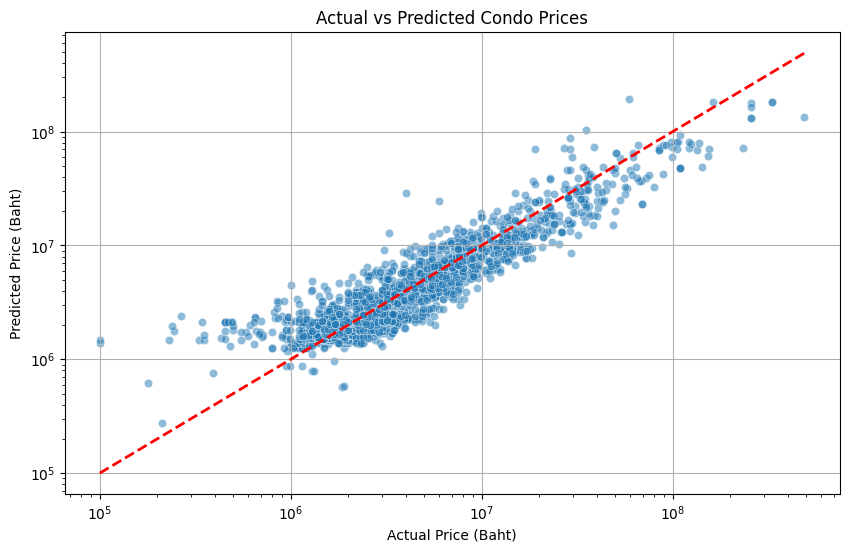

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # เรียกใช้ numpy

plt.figure(figsize=(10, 6))

# สร้าง Scatter Plot
sns.scatterplot(x=price_true, y=price_pred, alpha=0.5)

# เส้นสมมติ (Perfect Prediction)
# 💡 แก้ไข: ใช้ np.max และ np.min แทน max/min เฉยๆ
max_val = np.max([price_true.max(), price_pred.max()])
min_val = np.min([price_true.min(), price_pred.min()])

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual Price (Baht)')
plt.ylabel('Predicted Price (Baht)')
plt.title('Actual vs Predicted Condo Prices')

# ใช้ Log Scale เพื่อให้ดูกราฟง่ายขึ้น (เพราะราคาคอนโดมีความต่างกันสูงมาก)
plt.xscale('log') 
plt.yscale('log')

plt.grid(True)
plt.show()

In [ ]:
from pyspark.sql.functions import col

# 1. เลือกคอลัมน์ที่ต้องการ Export
df_score_export = df_joinedd

# 2. กำหนด Path ที่จะบันทึก (โปรดเปลี่ยนเป็น Path ที่เข้าถึงได้)
EXPORT_SCORE_PATH = "model_exports/livability_score_by_district.csv"

# 3. สั่งเขียนไฟล์ (ใช้ mode 'overwrite' และ singleFile=True เพื่อรวมเป็นไฟล์เดียว)
# การใช้ .coalesce(1) จะรวม Partition ทั้งหมดเป็นไฟล์เดียว ทำให้ง่ายต่อการใช้งาน
df_score_export.coalesce(1).write.mode("overwrite").csv(
    EXPORT_SCORE_PATH, 
    header=True # ใส่ header
)

print(f"✅ Export ตาราง Livability Score ไปที่: {EXPORT_SCORE_PATH} (เป็นไฟล์ CSV)")

# หมายเหตุ: หากไฟล์ถูกเขียนเป็นโฟลเดอร์ใน PySpark/HDFS ให้หาไฟล์ที่ชื่อ part-xxxxx.csv ภายในโฟลเดอร์นั้น

In [ ]:
df_final_ml.show()

+--------------------+---------+
|            features|    label|
+--------------------+---------+
|[100.0,2.0,2.0,7.12]|6480000.0|
| [37.0,1.0,1.0,7.12]|3500000.0|
|[118.0,2.0,2.0,7.12]|7050000.0|
| [41.0,1.0,1.0,7.12]|2790000.0|
|[100.0,2.0,2.0,7.12]|6320000.0|
| [42.0,1.0,1.0,7.12]|2900000.0|
| [95.0,2.0,2.0,7.12]|6320000.0|
| [40.0,1.0,1.0,7.12]|5459000.0|
| [42.0,1.0,1.0,7.12]|2990000.0|
|[186.0,3.0,3.0,7.13]|   3.16E7|
|[102.0,2.0,2.0,7.13]|   1.92E7|
| [47.0,1.0,1.0,7.13]|6890000.0|
| [35.0,1.0,1.0,7.13]|5440000.0|
| [73.0,2.0,2.0,7.13]|7650000.0|
| [94.0,3.0,2.0,7.13]|  1.214E7|
| [58.0,2.0,1.0,7.13]|5485500.0|
| [51.0,1.0,1.0,7.13]|6840000.0|
| [50.0,1.0,1.0,7.13]|7890000.0|
| [50.0,1.0,1.0,7.13]|7190000.0|
| [35.0,1.0,1.0,7.13]|5350000.0|
+--------------------+---------+
only showing top 20 rows
